In [1]:
import os
import torch
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
import torchvision.transforms.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from torchinfo import summary
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
print("Torch version: ", torch.__version__)
print("Numpy version: ", np.__version__)
print("Pandas version: ", pd.__version__)
print("Seaborn version: ", sns.__version__)
# print("TQDM version: ", tqdm.__version__)

Torch version:  2.13.0
Numpy version:  2.5.1
Pandas version:  3.0.3
Seaborn version:  0.13.2


In [3]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")
  
print(f"Running on device: {device}")

Running on device: mps


In [4]:
images = os.listdir("all_data")
print(f"Number of images: {len(images)}")

Number of images: 5676


## Visualizing the Data

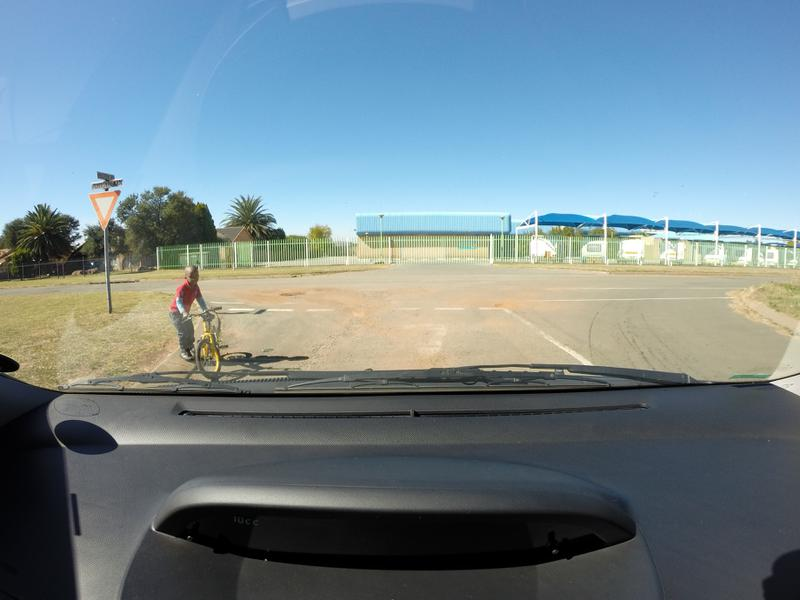

In [5]:
Image.open("all_data/aAAwuvUBxwBSvhR.JPG")

In [6]:
# Check if all the images have the same size
img_sizes = []
for img in tqdm(images):
  img_sizes.append(Image.open("all_data" + "/" + img).size)

img_sizes = torch.tensor(img_sizes)
img_sizes.unique()

100%|██████████| 5676/5676 [00:01<00:00, 4963.02it/s]


tensor([600, 800])

In [7]:
class ImageDataset(Dataset):
  def __init__(self, img_dir, csv_file, transforms=None):
    """
    Args:
      img_dir (string): Path to the image folder directory.
      csv_file (string): Path to the csv file containing image ids and labels.
      transforms (callable, optional): Optional transform to be applied to a sample.
    """
    # load the CSV into a pandas dataframe
    self.image_labels = pd.read_csv(csv_file)
    self.img_dir = img_dir
    self.transforms = transforms
    self.classes = self.image_labels.iloc[:, 1].unique()
    self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
  
  def __len__(self):
    return len(self.image_labels) 
  
  def __getitem__(self, row_index):
    # Get the image file name from CSV
    img_name = self.image_labels.iloc[row_index, 0]
    img_path = os.path.join(self.img_dir, img_name + ".JPG")
    
    # load the image using PIL
    image = Image.open(img_path)
    
    # get the corresponding image label
    label = self.image_labels.iloc[row_index, 1]
    
    if self.transforms:
      image = self.transforms(image)
    
    return image, label

In [8]:
import random

def show_samples(dataset, n=10):
  indices = random.sample(range(0, len(dataset)), n)
  samples = [dataset[i] for i in indices]
  imgs, labels = zip(*samples)
  grid = make_grid(list(imgs), nrow=5)
  plt.figure(figsize=(12, 6))
  plt.imshow(grid.permute(1, 2, 0))
  plt.axis("off")
  plt.show()

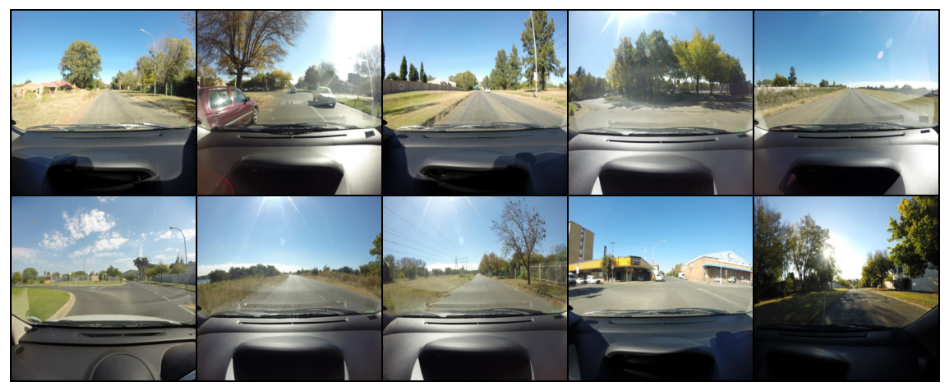

In [9]:
basic_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageDataset(
  img_dir="all_data",
  csv_file="train_ids_labels.csv",
  transforms=basic_transforms
)

show_samples(dataset)

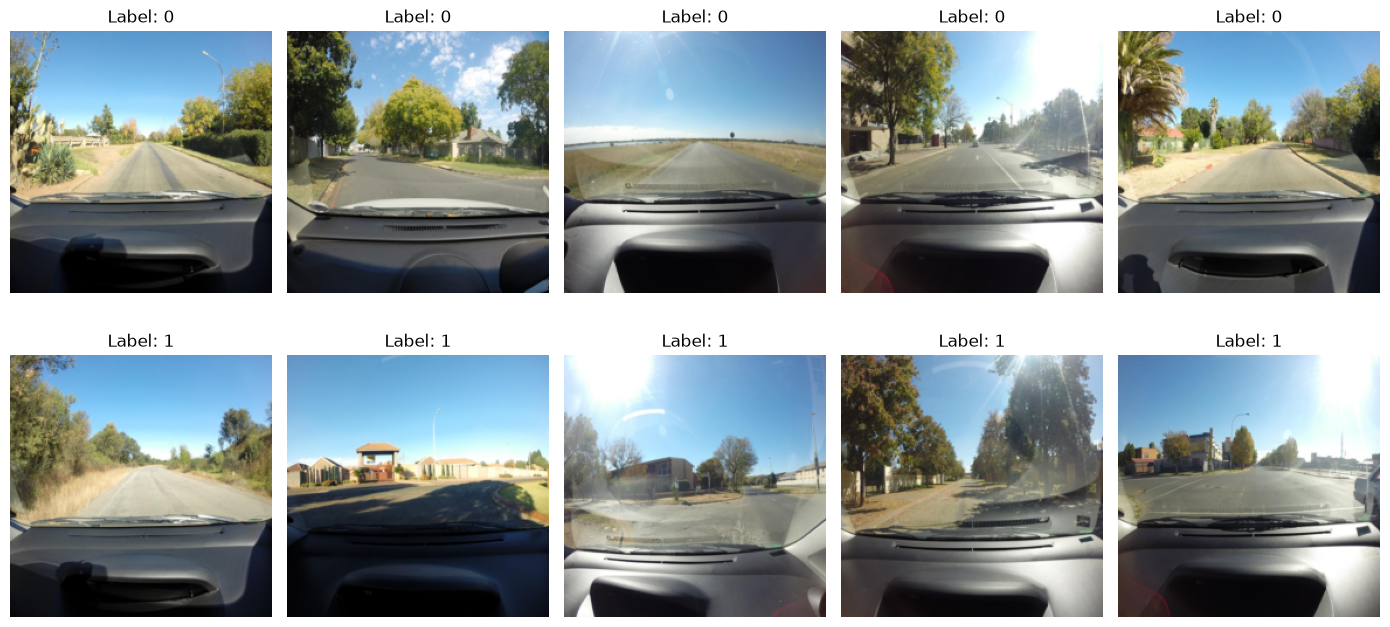

In [10]:
def show_balanced_samples(dataset, n_per_class=5, figsize=(14, 7)):
  negative_indices, positive_indices = [], []
  for i in range(len(dataset)):
    if isinstance(dataset, ImageDataset):
      label = dataset.image_labels.iloc[i, 1] 
    else:
      label = dataset.dataset.image_labels.iloc[i, 1]
    if label == 1:
      positive_indices.append(i)
    else:
      negative_indices.append(i)
      
  sampled_negatives = random.sample(negative_indices, n_per_class)
  sampled_positives = random.sample(positive_indices, n_per_class)
  selected_indices = sampled_negatives + sampled_positives
      
  fig, axes = plt.subplots(nrows=2, ncols=n_per_class, figsize=figsize)
  flat_axes = axes.flatten()
  for ax, idx in zip(flat_axes, selected_indices):
    img, label = dataset[idx]
    
    # img shape is [C, H, W], matplotlib expects [H, W, C]
    img = img.permute(1, 2, 0)
    
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
  plt.tight_layout()
  plt.show()
  
show_balanced_samples(dataset)

## Train Dataset

In [11]:
batch_size = 32

## Validation dataset

## Modeling

In [12]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

In [13]:
# LR scheduler
# scheduler = StepLR(
#   optimizer,
#   step_size=4,
#   gamma=0.2
# )

# Early stopping
def early_stopping(validation_loss, best_val_loss, counter, patience=5):
  stop = False
  if validation_loss < best_val_loss:
    counter = 0
  else:
    counter += 1
  
  if counter >= patience:
    stop = True
    
  return counter, stop

# Checkpointing
def checkpointing(validation_loss, model, optimizer, save_path):
  torch.save(
    {
              "model_state_dict": model.state_dict(),
              "optimizer_state_dict": optimizer.state_dict(),
              "loss": validation_loss,
          },
          save_path,
  )
  print(f"Checkpoint saved with validation loss {validation_loss:.4f}")

In [14]:
def train_epoch(model, optimizer, loss_fn, data_loader, device="mps"):
  training_loss = 0.0
  model.train() # set model to traing mode
  
  for imgs, labels in tqdm(data_loader, desc="Training model", leave=False):
    optimizer.zero_grad() # for each batch, start with zero gradients
    imgs = imgs.to(device)
    # labels = labels.to(device)
    labels = labels.to(device).float().unsqueeze(1) # for BCEWithLogitsLoss, labels must be floats and have same shape as output
    # print(labels.unique())
    
    output = model(imgs) # forward pass
    loss = loss_fn(output, labels) # compute loss
    
    loss.backward() # backprop
    optimizer.step() # 
    
    training_loss += loss.data.item() * imgs.size(0)
    
  return training_loss / len(data_loader.dataset)

In [15]:
def score(model, loss_fn, data_loader, device="mps"):
  total_loss = 0
  total_correct = 0
  model.eval()
  
  with torch.no_grad():
    for imgs, labels in tqdm(data_loader, desc="Scoring", leave=False):
      imgs = imgs.to(device)
      labels = labels.to(device).float().unsqueeze(1)
      
      output = model(imgs)
      loss = loss_fn(output, labels)

      probs = torch.sigmoid(output)
      preds = (probs >= 0.5).float()

      correct = torch.eq(preds, labels)
      total_correct += correct.sum().item()
      
      total_loss += loss.data.item() * imgs.size(0) # compute total loss
      
  average_loss = total_loss / len(data_loader.dataset)
  accuracy = total_correct / len(data_loader.dataset)
  return average_loss, accuracy

In [16]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="mps", scheduler=None, checkpoint_path=None, early_stopping=None):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    learning_rates = []

    best_val_loss = float("inf")
    early_stopping_counter = 0

    print("Model evaluation before start of training...")
    train_loss, train_accuracy = score(model, loss_fn, train_loader, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    validation_loss, validation_accuracy = score(model, loss_fn, val_loader, device)
    val_losses.append(validation_loss)
    val_accuracies.append(validation_accuracy)

    for epoch in range(1, epochs + 1):
        print("\n")
        print(f"Starting epoch {epoch}/{epochs}")

        train_epoch(model, optimizer, loss_fn, train_loader, device)

        train_loss, train_accuracy = score(model, loss_fn, train_loader, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        validation_loss, validation_accuracy = score(model, loss_fn, val_loader, device)
        val_losses.append(validation_loss)
        val_accuracies.append(validation_accuracy)

        print(f"Epoch: {epoch}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Training accuracy: {train_accuracy*100:.4f}%")
        print(f"Validation loss: {validation_loss:.4f}")
        print(f"Validation accuracy: {validation_accuracy*100:.4f}%")

        lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(lr)

        if scheduler:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(validation_loss)
            else:
                scheduler.step()

        prev_best = best_val_loss
        
        improved = validation_loss < prev_best
        if checkpoint_path and improved:
            checkpointing(validation_loss, model, optimizer, checkpoint_path)

        if early_stopping:
            early_stopping_counter, stop = early_stopping(validation_loss, prev_best, early_stopping_counter)
            if stop:
                print(f"Early stopping triggered after {epoch} epochs")
                break

        if improved:
            best_val_loss = validation_loss

    return (
        learning_rates,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies,
        epoch,
    )

In [17]:
def plot_training_results(train_results, figsize=(16, 4)):
    (
        learning_rates,
        train_losses,
        valid_losses,
        train_accuracies,
        valid_accuracies,
        epochs,
    ) = train_results

    num_epochs = min(
        len(train_losses),
        len(valid_losses),
        len(train_accuracies),
        len(valid_accuracies),
    )

    epoch_values = list(range(1, num_epochs + 1))

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)

    axes[0].plot(epoch_values, train_losses[:num_epochs], marker="o", label="Train")
    axes[0].plot(epoch_values, valid_losses[:num_epochs], marker="o", label="Validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epoch_values, train_accuracies[:num_epochs], marker="o", label="Train")
    axes[1].plot(epoch_values, valid_accuracies[:num_epochs], marker="o", label="Validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    lr_epoch_values = list(range(1, len(learning_rates) + 1))

    axes[2].plot(lr_epoch_values, learning_rates, marker="o", color="tab:green")
    axes[2].set_title("Learning Rate")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Learning Rate")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# plot_training_results(train_results, figsize=(16, 4))

## Implementing Transfer Learning

In [18]:
from torch.utils.data import Subset, random_split

base_dataset = ImageDataset(
    img_dir="all_data",
    csv_file="train_ids_labels.csv",
    transforms=None
)

train_size = int(0.8 * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

In [19]:
# Using imagenet's statistics for normalization to ensure we have similar input distribution as what ResNet was pretrained on
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms_resnet = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_transforms_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset_full_resnet = ImageDataset(
    img_dir="all_data",
    csv_file="train_ids_labels.csv",
    transforms=train_transforms_resnet,
)
val_dataset_full_resnet = ImageDataset(
    img_dir="all_data",
    csv_file="train_ids_labels.csv",
    transforms=val_transforms_resnet,
)
 
train_dataset_resnet = Subset(train_dataset_full_resnet, train_subset.indices)
val_dataset_resnet = Subset(val_dataset_full_resnet, val_subset.indices)
 
train_dataloader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_dataloader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)

In [20]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
test_batch = next(iter(train_dataloader_resnet))[0]
batch_shape = test_batch.shape

summary(model, input_size=batch_shape)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 1000]                --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│

In [21]:
list(model.named_modules())[-1]

('fc', Linear(in_features=512, out_features=1000, bias=True))

In [22]:

def build_resnet18(freeze_backbone=True):
  model = resnet18(weights=ResNet18_Weights.DEFAULT)
  model.fc = nn.Linear(model.fc.in_features, 1)
  
  if freeze_backbone:
    for name, param in model.named_parameters():
      if not name.startswith('fc.'): # don't freeze the last layer
        param.requires_grad = False
        
  return model

In [23]:
model = build_resnet18(freeze_backbone=True)
model.to(device)

loss_fn = nn.BCEWithLogitsLoss()

### Phase 1: Training only the new head (backbone frozeen)

This adapts the classifier quicly without disturbing the pretrained features - much cheaper per epoch since most of the network is not beein backprorpagated through

Model evaluation before start of training...




Starting epoch 1/8


Epoch: 1
Training loss: 0.5322
Training accuracy: 77.2671%
Validation loss: 0.5539
Validation accuracy: 75.9305%
Checkpoint saved with validation loss 0.5539


Starting epoch 2/8


Epoch: 2
Training loss: 0.4679
Training accuracy: 81.1180%
Validation loss: 0.4861
Validation accuracy: 80.5211%
Checkpoint saved with validation loss 0.4861


Starting epoch 3/8


Epoch: 3
Training loss: 0.4256
Training accuracy: 82.1739%
Validation loss: 0.4587
Validation accuracy: 81.2655%
Checkpoint saved with validation loss 0.4587


Starting epoch 4/8


Epoch: 4
Training loss: 0.4217
Training accuracy: 81.5839%
Validation loss: 0.4585
Validation accuracy: 79.2804%
Checkpoint saved with validation loss 0.4585


Starting epoch 5/8


Epoch: 5
Training loss: 0.3983
Training accuracy: 82.9503%
Validation loss: 0.4401
Validation accuracy: 80.1489%
Checkpoint saved with validation loss 0.4401


Starting epoch 6/8


Epoch: 6
Training loss: 0.3910
Training accuracy: 82.6087%
Validation loss: 0.4425
Validation accuracy: 80.3970%


Starting epoch 7/8


Epoch: 7
Training loss: 0.4080
Training accuracy: 81.4907%
Validation loss: 0.4776
Validation accuracy: 75.8065%


Starting epoch 8/8


Epoch: 8
Training loss: 0.3800
Training accuracy: 83.0745%
Validation loss: 0.4252
Validation accuracy: 81.0174%
Checkpoint saved with validation loss 0.4252


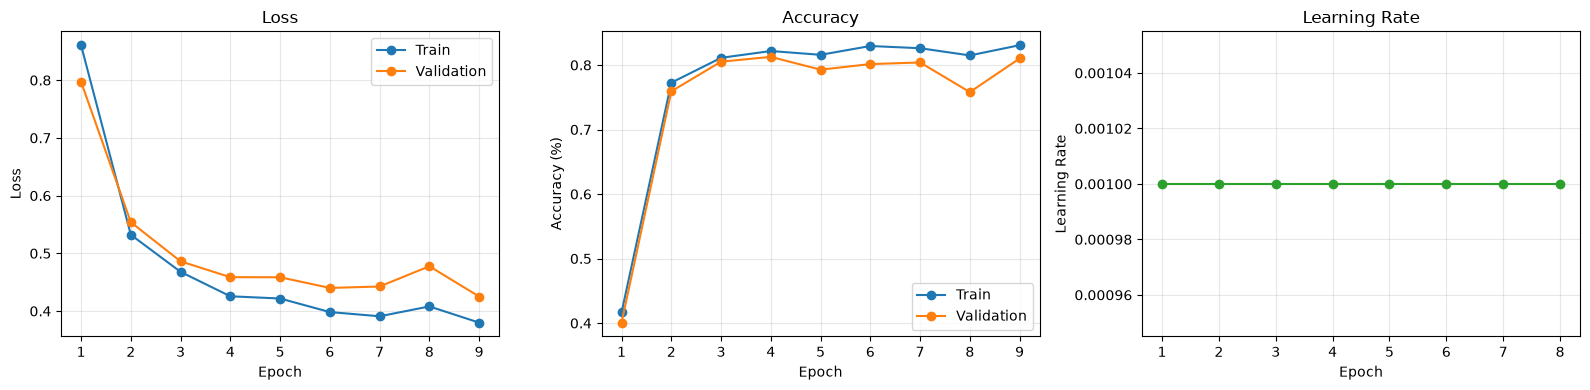

In [24]:
optimizer = optim.AdamW(
  filter(lambda p: p.requires_grad, model.parameters()), # filter out only parameters with requires_grad=True, in this case only the fc layer. Optional but shows intent and keeps optimizer internal state simpler
  lr=1e-3
)

scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

phase1_results = train(
    model,
    optimizer,
    loss_fn,
    train_dataloader_resnet,
    val_dataloader_resnet,
    epochs=8,
    device=device,
    scheduler=scheduler, 
    checkpoint_path="models/resnet_phase1.pth",
    early_stopping=early_stopping,
)

plot_training_results(phase1_results)

### Phase 2: Unfreeze and fine-tune the whole network

We will u se a smaller learning rate here -- the backbone weights are already good, and large updates at this stage will destroy the pretrained features

In [25]:
for param in model.parameters():
  param.requires_grad = True

optimizer= optim.AdamW(
  [
    {"params": model.fc.parameters(), "lr": 1e-4},
    {"params": (p for n, p in model.named_parameters() if not n.startswith("fc.")), "lr": 1e-5}
  ]
)

scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

In [26]:
# Reload best phase-1 weights before continuing
checkpoint = torch.load("models/resnet_phase1.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

phase2_results = train(
    model,
    optimizer,
    loss_fn,
    train_dataloader_resnet,
    val_dataloader_resnet,
    epochs=20,
    device=device,
    scheduler=scheduler,
    checkpoint_path="models/resnet_finetuned.pth",
    early_stopping=early_stopping,
)

Model evaluation before start of training...




Starting epoch 1/20


Epoch: 1
Training loss: 0.2304
Training accuracy: 91.3043%
Validation loss: 0.2717
Validation accuracy: 89.7022%
Checkpoint saved with validation loss 0.2717


Starting epoch 2/20


Epoch: 2
Training loss: 0.1799
Training accuracy: 93.2919%
Validation loss: 0.2156
Validation accuracy: 92.3077%
Checkpoint saved with validation loss 0.2156


Starting epoch 3/20


Epoch: 3
Training loss: 0.1498
Training accuracy: 94.6584%
Validation loss: 0.1939
Validation accuracy: 92.6799%
Checkpoint saved with validation loss 0.1939


Starting epoch 4/20


...

Epoch: 16
Training loss: 0.0303
Training accuracy: 99.0373%
Validation loss: 0.0972
Validation accuracy: 96.8983%


Starting epoch 17/20


Epoch: 17
Training loss: 0.0301
Training accuracy: 99.1304%
Validation loss: 0.0837
Validation accuracy: 97.5186%
Checkpoint saved with validation loss 0.0837


Starting epoch 18/20


Epoch: 18
Training loss: 0.0248
Training accuracy: 99.2857%
Validation loss: 0.0850
Validation accuracy: 97.2705%


Starting epoch 19/20


Epoch: 19
Training loss: 0.0191
Training accuracy: 99.5031%
Validation loss: 0.0831
Validation accuracy: 97.6427%
Checkpoint saved with validation loss 0.0831


Starting epoch 20/20


Epoch: 20
Training loss: 0.0198
Training accuracy: 99.4720%
Validation loss: 0.0791
Validation accuracy: 97.8908%
Checkpoint saved with validation loss 0.0791


In [32]:
# training for more epochs
checkpoint = torch.load("models/resnet_finetuned.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

phase2_results = train(
    model,
    optimizer,
    loss_fn,
    train_dataloader_resnet,
    val_dataloader_resnet,
    epochs=20,
    device=device,
    scheduler=scheduler,
    checkpoint_path="models/resnet_finetuned.pth",
    early_stopping=early_stopping,
)

Model evaluation before start of training...




Starting epoch 1/20


Epoch: 1
Training loss: 0.0153
Training accuracy: 99.6584%
Validation loss: 0.0668
Validation accuracy: 97.5186%
Checkpoint saved with validation loss 0.0668


Starting epoch 2/20


Epoch: 2
Training loss: 0.0147
Training accuracy: 99.6273%
Validation loss: 0.0703
Validation accuracy: 97.8908%


Starting epoch 3/20


Epoch: 3
Training loss: 0.0127
Training accuracy: 99.7516%
Validation loss: 0.0715
Validation accuracy: 98.1390%


Starting epoch 4/20


Epoch: 4
Training loss: 0.0164
Training accuracy: 99.5031%
Validation loss: 0.0693
Validation accuracy: 98.0149%


Starting epoch 5/20


Epoch: 5
Training loss: 0.0126
Training accuracy: 99.6894%
Validation loss: 0.0675
Validation accuracy: 98.2630%


Starting epoch 6/20


Epoch: 6
Training loss: 0.0125
Training accuracy: 99.7516%
Validation loss: 0.0731
Validation accuracy: 98.2630%
Early stopping triggered after 6 epochs


## Predicting on Test Data

In [33]:
def predict(model, data_loader):
  all_probs = torch.tensor([]).to(device)
  model.eval()
  
  with torch.no_grad():
    for img_batch in tqdm(data_loader, desc="Predicting", leave=False):
      img_batch = img_batch.to(device)
      # output = model(img_batch)
      
      # probs = torch.sigmoid(output)
      output = model(img_batch)
      # print("Raw logit:", output)

      probs = torch.sigmoid(output)
      # print("Probability:", probs)
      
      all_probs = torch.cat((all_probs, probs), dim=0)
  return all_probs

In [34]:
class ImageDatasetTest(Dataset):
  def __init__(self, img_dir, csv_file, transforms=None):
    """
    Args:
      img_dir (string): Path to the image folder directory.
      csv_file (string): Path to the csv file containing image ids only.
      transforms (callable, optional): Optional transform to be applied to a sample.
    """
    # load the CSV into a pandas dataframe
    self.image_ids = pd.read_csv(csv_file)
    self.img_dir = img_dir
    self.transforms = transforms
  
  def __len__(self):
    return len(self.image_ids) 
  
  def __getitem__(self, row_index):
    # Get the image file name from CSV
    image_id = self.image_ids.iloc[row_index, 0]
    img_path = os.path.join(self.img_dir, image_id + ".JPG")
    
    # load the image using PIL
    image = Image.open(img_path)
    
    if self.transforms:
      image = self.transforms(image)
    
    return image

In [35]:
test_transforms_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [36]:
test_dataset = ImageDatasetTest(
  img_dir="all_data",
  csv_file="test_ids_only.csv",
  transforms=test_transforms_resnet
)

In [45]:
checkpoint = torch.load("models/resnet_finetuned.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [38]:
next(model.parameters()).mean()

tensor(1.8571e-07, device='mps:0', grad_fn=<MeanBackward0>)

In [46]:
test_loader = DataLoader(test_dataset, batch_size=batch_size)
test_ids = pd.read_csv("test_ids_only.csv")["Image_ID"]
len(test_dataset), test_ids.shape

(1650, (1650,))

In [47]:

predictions = predict(model, test_loader)
predictions.shape

torch.Size([1650, 1])

In [48]:
predictions = predictions.cpu()
# predicted_labels = predictions[:, 1].numpy()

In [49]:

submission_df = pd.DataFrame({
  "Image_ID": test_ids,
  "Label": predictions.flatten()
})

In [51]:
submission_df.head()

,Image_ID,Label
0,nRhHxqLhDlJsiXc,0.366040
1,gbSntVovxgHQrmO,0.282075
2,nqOobGmvgEOiPms,0.000973
3,oIkPTooLcIbZKlF,0.999994
4,eSKxsTTJDQzkjgD,0.977949


In [52]:
submission_df.to_csv("submission.csv", index=False)
print(f"Submission saved! Rows: {len(submission_df)}")

Submission saved! Rows: 1650


## Asides

### Why Two Phases?
**The core problem: random head + pretrained backbone**

When you do `model.fc = nn.Linear(model.fc.in_features, 1)`, that new layer starts with random weights. Everything else in the network (all the conv layers) has good, pretrained weights that already know how to detect edges, textures, shapes, etc.

If you train the whole network at once, right from the start:

- The random head produces garbage predictions initially (it hasn't learned anything yet).

- This garbage causes large gradients to backpropagate through the entire network — including the pretrained backbone.

- Those large, early, noisy gradient updates can knock the pretrained backbone weights out of their good starting position before the head has had a chance to learn anything sensible. This is often called destroying the pretrained features, and once it happens, you've essentially thrown away the benefit of transfer learning — you're back to training from a semi-random state, just with extra steps.

Think of it like this: imagine you hire a highly experienced consultant (the backbone) and pair them with a brand-new intern (the head) who doesn't know anything yet. If you let the intern's confused, random first-week feedback directly influence and "correct" the consultant's expert judgment from day one, you risk degrading the consultant's expertise before the intern has learned enough to give useful feedback.

### What each phase actually does

* **Phase 1 (freeze backbone, train head only)**: The random head gets to learn a reasonable mapping from the (already good) pretrained features to your specific task — "does this pattern of features mean pothole or not" — without touching or disturbing the backbone at all. Only a few epochs are needed since it's a small layer.

* **Phase 2 (unfreeze everything, tiny LR on backbone)**: Now the head is no longer random — it produces sensible gradients. Unfreezing the backbone and fine-tuning with a very small LR lets the backbone features adapt slightly to your specific domain (e.g., road textures, asphalt colors, camera angles) without erasing what it already knows from ImageNet.

**Practical rule of thumb**: with a small-to-medium dataset, two-phase is worth the extra bit of code. If you had a huge dataset (100k+ images) closer in size to what these backbones were originally trained on, single-phase differential LR training from scratch is common and works fine, because with more data the gradients tend to be less noisy per batch and the risk of catastrophic forgetting drops.